/tmp/ipykernel_10223/2748751757.py:653: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  error_image = np.exp(error_image)


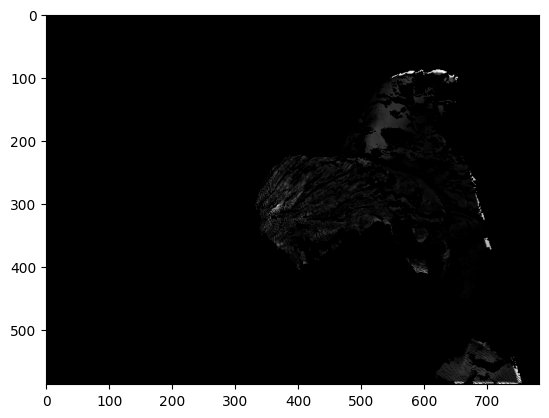

In [100]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import open3d as o3d
import os
import numpy as np


COLOR_DEFAULT=0
COLOR_GT=1
COLOR_OVERRIDE=2

COLOR_ATTR_NAMES = {
    COLOR_DEFAULT: "color",
    COLOR_GT: "gt_color",
    COLOR_OVERRIDE: "override_color",
}

ext = ".pth"
folder = "/tmp/test"
def to_key(f): 
    try: base = os.path.basename(f).removesuffix(ext); return None if len(base) == 0 else int(base)
    except: return None

files = sorted([
    os.path.join(folder, f) for f in os.listdir(folder)
    if os.path.isfile(os.path.join(folder, f)) and f.endswith(ext) and to_key(f) is not None
],key=to_key)
files = {to_key(f) : f for f in files}



def smooth_depth_with_normals(
    noisy_depth: torch.Tensor,
    clean_normals: torch.Tensor,
    intrinsics: tuple,
    lambda_val: float = 0.95,
    mask: torch.Tensor = None,
    max_iters: int = 50,
    tol: float = 1e-5
) -> torch.Tensor:
    
    # Handle single-frame dimensions safely
    if noisy_depth.ndim == 2:
        noisy_depth = noisy_depth.unsqueeze(0)
        
    _, H, W = noisy_depth.shape
    device = noisy_depth.device
    dtype = noisy_depth.dtype
    fx, fy, cx, cy = intrinsics

    if mask is None:
        mask = torch.ones_like(noisy_depth)
    elif mask.ndim == 2:
        mask = mask.unsqueeze(0)
    mask = mask.float()

    # 1. Compute pixel ray vectors r = [u, v, 1]^T
    y, x = torch.meshgrid(
        torch.arange(H, device=device, dtype=dtype),
        torch.arange(W, device=device, dtype=dtype),
        indexing='ij'
    )
    u = ((x - cx) / fx).unsqueeze(0)
    v = ((y - cy) / fy).unsqueeze(0)

    # 2. Extract normal channels
    nx = clean_normals[0:1, :, :]
    ny = clean_normals[1:2, :, :]
    nz = clean_normals[2:3, :, :]

    # Dot product: N . r
    N_dot_r = nx * u + ny * v + nz
    N_dot_r = torch.where(N_dot_r.abs() < 1e-6, torch.sign(N_dot_r) * 1e-6, N_dot_r)

    # 3. Compute target log-depth gradients
    gx = -nx / (fx * N_dot_r)
    gy = -ny / (fy * N_dot_r)

    # Ignore grazing angles where normal is perpendicular to the ray
    invalid_grad = (N_dot_r.abs() < 1e-3) | (mask == 0)
    gx[invalid_grad] = 0.0
    gy[invalid_grad] = 0.0

    # 4. Define log-depth target observation
    L_obs = torch.log(torch.clamp(noisy_depth, min=1e-5))

    # --- CRITICAL FIX: Compute Edge Weights ---
    # An edge is only active if BOTH connected pixels are inside the mask
    W_x = mask[..., :, 1:] * mask[..., :, :-1]
    W_y = mask[..., 1:, :] * mask[..., :-1, :]

    # --- Matrix-Free Operators ---
    def A_operator(L: torch.Tensor) -> torch.Tensor:
        # Forward differences
        dx = torch.zeros_like(L)
        dy = torch.zeros_like(L)
        dx[..., :, :-1] = L[..., :, 1:] - L[..., :, :-1]
        dy[..., :-1, :] = L[..., 1:, :] - L[..., :-1, :]
        
        # Multiply by edge weights to kill boundary bleeding
        dx[..., :, :-1] *= W_x
        dy[..., :-1, :] *= W_y
        
        # Adjoint difference (Weighted Negative Divergence)
        div = torch.zeros_like(L)
        div[..., :, :-1] -= dx[..., :, :-1]
        div[..., :, 1:] += dx[..., :, :-1]
        div[..., :-1, :] -= dy[..., :-1, :]
        div[..., 1:, :] += dy[..., :-1, :]
        
        return div + lambda_val * mask * L

    # Compute Weighted Right-Hand Side 'b'
    tgx = gx[..., :, :-1] * W_x
    tgy = gy[..., :-1, :] * W_y

    b = torch.zeros_like(L_obs)
    b[..., :, :-1] += tgx
    b[..., :, 1:] -= tgx
    b[..., :-1, :] += tgy
    b[..., 1:, :] -= tgy
    b = b + lambda_val * mask * L_obs

    # --- CG Loop ---
    L = L_obs.clone()
    r = b - A_operator(L)
    p = r.clone()
    
    rsold = torch.sum(r * r, dim=(-3, -2, -1), keepdim=True) 
    
    for i in range(max_iters):
        Ap = A_operator(p)
        pAp = torch.clamp(torch.sum(p * Ap, dim=(-3, -2, -1), keepdim=True), min=1e-10)
        
        alpha = rsold / pAp
        L = L + alpha * p
        r = r - alpha * Ap
        
        rsnew = torch.sum(r * r, dim=(-3, -2, -1), keepdim=True)
        if torch.max(rsnew) < tol:
            break
            
        p = r + (rsnew / rsold) * p
        rsold = rsnew

    # 5. Output cleanup
    smoothed_depth = torch.exp(L).squeeze(0)
    smoothed_depth[mask.squeeze(0) == 0] = 0
    return smoothed_depth

def dilate(binary_mask, kernel_size=3):
    pad = kernel_size // 2
    mask = binary_mask.float()

    mask_dilated = F.max_pool2d(
        mask[None, None],
        kernel_size=kernel_size,
        stride=1,
        padding=pad
    )[0, 0]

    return mask_dilated > 0

def erode(binary_mask, kernel_size=3):
    # replace invalid with +inf so they don't affect min
    pad = kernel_size // 2
    mask = binary_mask.float()
    # min-pool = -max-pool(-x)
    mask_eroded = 1-F.max_pool2d(
        (1-mask[None, None]),
        kernel_size=kernel_size,
        stride=1,
        padding=pad
    )[0, 0]

    return mask_eroded > 0



def unproject_depth(d, K, erode_depth=11):
    """
    d: (H, W) depth map
    K: (3, 3) camera intrinsics

    returns:
        points: (3, H, W)
    """
    H, W = d.shape
    device = d.device
    dtype = d.dtype
    
    if erode_depth > 1:
        mask_eroded = erode(d > 0, erode_depth)
        d = d * mask_eroded
        

    # pixel grid
    y, x = torch.meshgrid(
        torch.arange(H, device=device, dtype=dtype),
        torch.arange(W, device=device, dtype=dtype),
        indexing='ij'
    )

    # homogeneous pixels
    pix = torch.stack([x, y, torch.ones_like(x)], dim=0)  # (3, H, W)
    pix = pix.reshape(3, -1)                              # (3, N)

    # K^-1
    Kinv = torch.linalg.inv(K)

    # rays
    rays = Kinv @ pix                                     # (3, N)

    # scale by depth
    points = rays * d.reshape(1, -1)                      # (3, N)

    return points.reshape(3, H, W)

def load_pth(f, device="cuda"):
    D, N, C, C2, W2C, K = torch.load(f)
    return {
        "depth": D.to(device),
        "normal": N.to(device),
        COLOR_ATTR_NAMES[COLOR_DEFAULT]: C.to(device),
        COLOR_ATTR_NAMES[COLOR_GT]: C2.to(device),
        COLOR_ATTR_NAMES[COLOR_OVERRIDE]: None,
        "w2c": W2C.to(device).transpose(0,1),
        "K": K.to(device)
    }

def frame_compute_smooth_depth(frame):
    frame["smoothed_depth"]=smooth_depth_with_normals(frame["depth"], 
                                                      frame["normal"], 
                                                      (frame["K"][0,0], frame["K"][1,1], frame["K"][0,2], frame["K"][1,2]), 
                                                      mask=frame["depth"]>1e-6)

def frame_to_ply_frame(frame, smoothed_depth=True, device="cpu"):
    depth = frame["depth" if not smoothed_depth else "smoothed_depth"]
    mask = (depth > 0)
    
    return {"points": unproject_depth(depth, frame["K"])[:,mask].to(device).permute(1,0), 
            "normal": frame["normal"][:, mask].to(device).permute(1,0), 
            COLOR_ATTR_NAMES[COLOR_DEFAULT]: frame[COLOR_ATTR_NAMES[COLOR_DEFAULT]][:, mask].to(device).permute(1,0), 
            COLOR_ATTR_NAMES[COLOR_OVERRIDE]: None if frame[COLOR_ATTR_NAMES[COLOR_OVERRIDE]] is None else frame[COLOR_ATTR_NAMES[COLOR_OVERRIDE]][:,mask].to(device).permute(1,0),
            COLOR_ATTR_NAMES[COLOR_GT]: frame[COLOR_ATTR_NAMES[COLOR_GT]][:, mask].to(device).permute(1,0), 
            "w2c": frame["w2c"].to(device),
            "K": frame["K"].to(device)
            }

def ply_frame_to_o3d(frame_pcl, use_color=COLOR_GT, apply_c2w=False):
    P = frame_pcl["points"].numpy()
    C = frame_pcl[COLOR_ATTR_NAMES[use_color]].numpy()
    N = frame_pcl["normal"].numpy()
    o3d_pcl = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(P))
    o3d_pcl.colors = o3d.utility.Vector3dVector(C)
    o3d_pcl.normals = o3d.utility.Vector3dVector(N)
    if apply_c2w: o3d_pcl.transform(np.linalg.inv(frame_pcl["w2c"].numpy()))
    return o3d_pcl

def load_as_o3d(f, smooth_depth=True,use_color=COLOR_GT,apply_c2w=False):
    frame = load_pth(f)
    if smooth_depth: frame_compute_smooth_depth(frame)
    ply_frame = frame_to_ply_frame(frame, smooth_depth, "cpu")
    o3d_pcl = ply_frame_to_o3d(ply_frame, use_color=use_color, apply_c2w=apply_c2w)
    return o3d_pcl

def rgb_to_lab(img: torch.Tensor) -> torch.Tensor:
    """
    Convert RGB image in [0,1] to CIE LAB.

    Args:
        img: Tensor of shape (..., 3, H, W) or (3, H, W)
             Values assumed in [0,1]

    Returns:
        lab: Tensor with same shape as input
             L in [0,100]
             a roughly in [-128,127]
             b roughly in [-128,127]
    """

    orig_shape = img.shape

    # Handle single image
    if img.ndim == 3:
        img = img.unsqueeze(0)

    # ------------------------------------------------------------
    # 1. sRGB -> linear RGB
    # ------------------------------------------------------------

    limit = 0.04045

    linear = torch.where(
        img <= limit,
        img / 12.92,
        ((img + 0.055) / 1.055).clamp(min=1e-6).pow(2.4)
    )

    r = linear[:, 0:1]
    g = linear[:, 1:2]
    b = linear[:, 2:3]

    # ------------------------------------------------------------
    # 2. linear RGB -> XYZ (D65)
    # ------------------------------------------------------------

    X = 0.4124564 * r + 0.3575761 * g + 0.1804375 * b
    Y = 0.2126729 * r + 0.7151522 * g + 0.0721750 * b
    Z = 0.0193339 * r + 0.1191920 * g + 0.9503041 * b

    # ------------------------------------------------------------
    # 3. Normalize by D65 white point
    # ------------------------------------------------------------

    Xn = 0.95047
    Yn = 1.00000
    Zn = 1.08883

    x = X / Xn
    y = Y / Yn
    z = Z / Zn

    # ------------------------------------------------------------
    # 4. XYZ -> LAB
    # ------------------------------------------------------------

    epsilon = 216.0 / 24389.0
    kappa = 24389.0 / 27.0

    def f(t):
        return torch.where(
            t > epsilon,
            t.clamp(min=1e-6).pow(1.0 / 3.0),
            (kappa * t + 16.0) / 116.0
        )

    fx = f(x)
    fy = f(y)
    fz = f(z)

    L = 116.0 * fy - 16.0
    a = 500.0 * (fx - fy)
    b = 200.0 * (fy - fz)
    
    L = L / 100.0
    a = (a) / 255.0
    b = (b) / 255.0
    lab = torch.cat([L, a, b], dim=1)

    # restore original shape
    if len(orig_shape) == 3:
        lab = lab.squeeze(0)

    return lab

def rgb_to_luminance_lab(img: torch.Tensor) -> torch.Tensor:
    """
    Converts an RGB image [0, 1] to the perceptually uniform L* (Lightness) 
    channel of the CIE L*a*b* space, scaled back to [0, 1].
    Args:
        img: (3, H, W) tensor, values assumed to be in range [0, 1]
    """
    # 1. Inverse sRGB gamma companding (convert to linear RGB)
    # This undoes the camera's internal gamma encoding
    limit = 0.04045
    linear_img = torch.where(
        img <= limit, 
        img / 12.92, 
        torch.pow(torch.clamp(img + 0.055, min=1e-5) / 1.055, 2.4)
    )
    
    # 2. Linear RGB to CIE XYZ space conversion matrix
    r, g, b = linear_img[0:1], linear_img[1:2], linear_img[2:3]
    
    # We only strictly need the 'Y' channel of XYZ, because L* is derived entirely from Y!
    # Y represents the absolute CIE tristimulus luminance.
    Y = 0.2126729 * r + 0.7151522 * g + 0.0721750 * b
    
    # 3. XYZ to L* conversion (normalized by standard D65 white point where Yn = 1.0)
    epsilon = 216.0 / 24389.0  # ~0.008856
    kappa = 24389.0 / 27.0     # ~903.3
    
    # Non-linear function f(Y)
    f_Y = torch.where(
        Y > epsilon,
        torch.pow(torch.clamp(Y, min=1e-6), 1.0 / 3.0),
        (kappa * Y + 16.0) / 116.0
    )
    
    # Standard L* formula yields values from 0.0 to 100.0
    L_star = 116.0 * f_Y - 16.0
    
    # Normalize back to [0, 1] so it scales cleanly with your Sobel filters
    return L_star / 100.0

def compute_structure_tensor(img: torch.Tensor):
    """
    Computes the three unique components of the 2D Structure Tensor field.
    Args:
        img: (3, H, W) or (1, H, W) image tensor
    Returns:
        Ixx, Iyy, Ixy: Tensors of shape (H, W) representing local structure
    """
    # Convert to grayscale if it is RGB
    if img.shape[0] == 3:
        # Use the robust L* channel instead of simple grayscale
        gray = rgb_to_luminance_lab(img)
    else:
        gray = img
        
    # Define Sobel filters for spatial gradients
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=img.dtype, device=img.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=img.dtype, device=img.device).view(1, 1, 3, 3)
    
    # Compute gradients via convolution
    Ix = F.conv2d(F.pad(gray.unsqueeze(0), (1,1,1,1), mode='replicate'), sobel_x).squeeze(0).squeeze(0)
    Iy = F.conv2d(F.pad(gray.unsqueeze(0), (1,1,1,1), mode='replicate'), sobel_y).squeeze(0).squeeze(0)
    
    # Construct tensor components (optionally apply a local Gaussian blur window here)
    Ixx = Ix * Ix
    Iyy = Iy * Iy
    Ixy = Ix * Iy
    
    return Ixx, Iyy, Ixy

def _reproject_geometry_backbone(src, tgt, smooth_depth=True):
    """
    Shared backbone that handles unprojection, transformation, projection, 
    bounds filtering, and adaptive IQR depth testing.
    """
    if smooth_depth:
        frame_compute_smooth_depth(src)
        frame_compute_smooth_depth(tgt)
        
    src_depth = src["smoothed_depth"] if smooth_depth else src["depth"]
    tgt_depth = tgt["smoothed_depth"] if smooth_depth else tgt["depth"]
    H, W = src_depth.shape
    
    # Extract Valid Source Point Clouds
    src_mask = src_depth > 1e-6
    if src_mask.sum() == 0:
        return None
        
    src_pts_cam = unproject_depth(src_depth, src["K"])[:, src_mask]
    N = src_pts_cam.shape[1]
    
    # Homogeneous coordinates for projection
    src_pts_cam_homo = torch.cat([
        src_pts_cam, 
        torch.ones((1, N), device=src_pts_cam.device, dtype=src_pts_cam.dtype)
    ], dim=0)
    
    # Transform: Source Cam -> World -> Target Cam Space
    c2w_src = torch.linalg.inv(src["w2c"])
    T_src_to_tgt = tgt["w2c"] @ c2w_src
    
    tgt_pts_cam_homo = T_src_to_tgt @ src_pts_cam_homo
    tgt_pts_cam = tgt_pts_cam_homo[:3, :]
    computed_tgt_depths = tgt_pts_cam[2, :]
    
    # Project onto Target Screen space using K_tgt
    screen_homo = tgt["K"] @ tgt_pts_cam
    u_reproj = screen_homo[0, :] / (screen_homo[2, :] + 1e-8)
    v_reproj = screen_homo[1, :] / (screen_homo[2, :] + 1e-8)
    
    u_idx = torch.round(u_reproj).long()
    v_idx = torch.round(v_reproj).long()
    
    # Filter out-of-bounds projections
    in_bounds = (u_idx >= 0) & (u_idx < W) & (v_idx >= 0) & (v_idx < H) & (computed_tgt_depths > 1e-6)
    if in_bounds.sum() == 0:
        return None
        
    u_idx = u_idx[in_bounds]
    v_idx = v_idx[in_bounds]
    computed_tgt_depths = computed_tgt_depths[in_bounds]
    
    # Extract structural mask tracking from source indices
    # We need this mask to slice whatever feature maps/colors the head functions want
    src_mask_indices = torch.where(src_mask.flatten())[0][in_bounds]
    
    # Sample actual target depths
    actual_tgt_depths = tgt_depth[v_idx, u_idx]
    valid_tgt_pixels = actual_tgt_depths > 1e-6
    if valid_tgt_pixels.sum() == 0:
        return None
        
    u_idx = u_idx[valid_tgt_pixels]
    v_idx = v_idx[valid_tgt_pixels]
    computed_tgt_depths = computed_tgt_depths[valid_tgt_pixels]
    actual_tgt_depths = actual_tgt_depths[valid_tgt_pixels]
    src_mask_indices = src_mask_indices[valid_tgt_pixels]
    
    # Adaptive IQR Depth Testing
    depth_diffs = (computed_tgt_depths - actual_tgt_depths).abs()
    q05 = torch.quantile(depth_diffs, 0.05)
    q15 = torch.quantile(depth_diffs, 0.15)
    epsilon = torch.clamp((q15 - q05) * 3.5, min=1e-5, max=0.03)
    
    visible_mask = depth_diffs <= epsilon
    if visible_mask.sum() == 0:
        return None
        
    return {
        "u_idx": u_idx[visible_mask],
        "v_idx": v_idx[visible_mask],
        "src_mask_indices": src_mask_indices[visible_mask],
        "H": H, "W": W
    }

def reproj_to_other_frame_structure_tensor(src, tgt, smooth_depth=True, gt_color=True):
    # 1. Run the shared geometric backbone
    geo = _reproject_geometry_backbone(src, tgt, smooth_depth)
    if geo is None:
        H, W = (src["smoothed_depth"] if smooth_depth else src["depth"]).shape
        return torch.zeros((H, W), device=src["w2c"].device)
        
    # 2. Extract image labels and compute structure tensors
    color_attr = COLOR_ATTR_NAMES[COLOR_GT if gt_color else COLOR_DEFAULT]
    src_Ixx, src_Iyy, src_Ixy = compute_structure_tensor(src[color_attr])
    tgt_Ixx, tgt_Iyy, tgt_Ixy = compute_structure_tensor(tgt[color_attr])
    
    # 3. Sample values at the shared validated indices
    # Source tensor maps need 1D flattening to be sliced via the tracked source mask indices
    src_Ixx_valid = src_Ixx.flatten()[geo["src_mask_indices"]]
    src_Iyy_valid = src_Iyy.flatten()[geo["src_mask_indices"]]
    src_Ixy_valid = src_Ixy.flatten()[geo["src_mask_indices"]]
    
    tgt_Ixx_valid = tgt_Ixx[geo["v_idx"], geo["u_idx"]]
    tgt_Iyy_valid = tgt_Iyy[geo["v_idx"], geo["u_idx"]]
    tgt_Ixy_valid = tgt_Ixy[geo["v_idx"], geo["u_idx"]]
    
    # 4. Compute Frobenius Norm Error
    diff_xx = src_Ixx_valid - tgt_Ixx_valid
    diff_yy = src_Iyy_valid - tgt_Iyy_valid
    diff_xy = src_Ixy_valid - tgt_Ixy_valid
    tensor_errors = torch.sqrt(diff_xx**2 + diff_yy**2 + 2.0 * (diff_xy**2))
    
    # 5. Project back onto Canvas
    error_image = torch.zeros((geo["H"], geo["W"]), device=tensor_errors.device, dtype=torch.float32)
    error_image[geo["v_idx"], geo["u_idx"]] = tensor_errors
    
    return error_image

def reproj_to_other_frame_window(src, tgt, window_size=3, smooth_depth=True, gt_color=True, use_lab=True):
    """
    Computes a patch-based window error (MAE across a KxK neighborhood) 
    between reprojected source image properties and target properties.
    """
    assert window_size % 2 == 1, "Window size K must be an odd integer."
    
    # 1. Run the shared geometric backbone
    geo = _reproject_geometry_backbone(src, tgt, smooth_depth)
    if geo is None:
        H, W = (src["smoothed_depth"] if smooth_depth else src["depth"]).shape
        return torch.zeros((H, W), device=src["w2c"].device)
        
    # 2. Get the target image properties (Convert to LAB space if requested)
    color_attr = COLOR_ATTR_NAMES[COLOR_GT if gt_color else COLOR_DEFAULT]
    src_img = src[color_attr] # Expected shape: (C, H, W)
    tgt_img = tgt[color_attr]
    
    if use_lab and src_img.shape[0] == 3:
        # Reuses the conversion logic discussed previously to isolate L*
        src_img = rgb_to_luminance_lab(src_img) # (1, H, W)
        tgt_img = rgb_to_luminance_lab(tgt_img)
        
    C, H, W = src_img.shape
    pad = window_size // 2

    # 3. Extract sliding windows using unfold
    # Add batch dimension for unfold: (1, C, H, W)
    src_padded = F.pad(src_img.unsqueeze(0), (pad, pad, pad, pad), mode='replicate')
    tgt_padded = F.pad(tgt_img.unsqueeze(0), (pad, pad, pad, pad), mode='replicate')
    
    # Unfold turns patches into columns. Output shape: (1, C * K * K, H * W)
    src_patches = F.unfold(src_padded, kernel_size=window_size).squeeze(0) # (C*K*K, H*W)
    tgt_patches = F.unfold(tgt_padded, kernel_size=window_size).squeeze(0) # (C*K*K, H*W)
    
    # 4. Slice patches corresponding to the valid geometry tracks
    # src features are sliced using the flat 1D spatial array indices
    src_patches_valid = src_patches[:, geo["src_mask_indices"]] # (C*K*K, N_visible)
    
    # target features are sliced by converting 2D pixel coordinates to flat 1D coordinates
    flat_tgt_indices = geo["v_idx"] * W + geo["u_idx"]
    tgt_patches_valid = tgt_patches[:, flat_tgt_indices] # (C*K*K, N_visible)
    
    # 5. Compute the neighborhood window error 
    # Here we use Mean Absolute Error (L1) over the window elements
    window_errors = torch.mean(torch.abs(src_patches_valid - tgt_patches_valid), dim=0) # (N_visible,)
    
    # 6. Project error back onto Canvas
    error_image = torch.zeros((H, W), device=window_errors.device, dtype=torch.float32)
    error_image[geo["v_idx"], geo["u_idx"]] = window_errors
    
    return error_image

def map_error_to_magma(error_image: torch.Tensor) -> torch.Tensor:
    """
    Maps a 2D error tensor with values in range (0, 1) to a 3D RGB image
    using the matplotlib 'magma' colormap.
    
    Args:
        error_image: (H, W) tensor containing error values clamped/normalized to [0, 1]
        
    Returns:
        rgb_image: (3, H, W) tensor in float32, range [0, 1], matching the input device
    """
    device = error_image.device
    dtype = error_image.dtype
    H, W = error_image.shape

    # 1. Ensure inputs are strictly clamped between 0 and 1
    error_clamped = torch.clamp(error_image, 0.0, 1.0)

    # 2. Extract the magma colormap look-up table (LUT) from matplotlib
    # magma has 256 discrete color steps. Shape: (256, 4) -> [R, G, B, A]
    magma_lut = torch.tensor(cm.magma.colors, dtype=dtype, device=device)
    
    # Drop the Alpha channel, leaving just RGB. Shape: (256, 3)
    magma_rgb_lut = magma_lut[:, :3]

    # 3. Convert continuous (0, 1) error values into discrete LUT indices [0, 255]
    indices = torch.round(error_clamped * 255.0).long()

    # 4. Vectorized gather: Map indices to RGB channels
    # Flatten temporarily to make indexing trivial, then reshape back
    rgb_flat = magma_rgb_lut[indices.view(-1)] # Shape: (H*W, 3)
    
    # Reshape to (H, W, 3) and permute to standard PyTorch image layout (3, H, W)
    rgb_image = rgb_flat.view(H, W, 3).permute(2, 0, 1)

    return rgb_image
    
pcl0 = load_as_o3d(files[0], False,COLOR_DEFAULT, True)
for i in files.keys():
    if i == 0:break 
    if i % 10 != 0: continue
    pcl0 = pcl0 + load_as_o3d(files[i], False,COLOR_DEFAULT, True)
    #pcl0 = pcl0.voxel_down_sample(1e-2)




f_test = load_pth(files[0],"cuda")
frame_compute_smooth_depth(f_test)


error_image = reproj_to_other_frame_window(load_pth(files[250]), load_pth(files[0]), use_lab=True).cpu()
error_image = np.exp(error_image)
plt.imshow(error_image.numpy(),vmin=error_image.min().item(), vmax=error_image.max().item(), cmap="gray")
f_test[COLOR_ATTR_NAMES[COLOR_OVERRIDE]] = map_error_to_magma((error_image-error_image.min())/(error_image.max()-error_image.min())).cuda()
ply_frame = frame_to_ply_frame(f_test)
o3d_with_errors = ply_frame_to_o3d(ply_frame, COLOR_OVERRIDE)


o3d.visualization.draw_geometries([pcl0])
o3d.visualization.draw_geometries([o3d_with_errors])

In [103]:
import torch
import torch.nn.functional as F
import cv2


def local_ncc(img1, img2, K=9, eps=1e-8, lab_conversion=True):
    """
    Compute local normalized cross-correlation (NCC) between two images.

    Args:
        img1: Tensor of shape [B, C, H, W]
        img2: Tensor of shape [B, C, H, W]
        K: window size
        eps: numerical stability constant

    Returns:
        ncc: Tensor of shape [B, C, H, W]
    """

    B, C, H, W = img1.shape
    assert img1.shape == img2.shape
    if lab_conversion and C == 3: 
        img1 = torch.stack([rgb_to_lab(img1[i]) for i in range(B)])
        img2 = torch.stack([rgb_to_lab(img2[i]) for i in range(B)])

    pad = K // 2

    # Mean filter kernel
    kernel = torch.ones((C, 1, K, K), device=img1.device, dtype=img1.dtype)
    kernel = kernel / (K * K)

    # Local means
    mu1 = F.conv2d(img1, kernel, padding=pad, groups=C)
    mu2 = F.conv2d(img2, kernel, padding=pad, groups=C)

    # Local variances and covariance
    mu1_sq = mu1 * mu1
    mu2_sq = mu2 * mu2
    mu12 = mu1 * mu2

    sigma1_sq = (
        F.conv2d(img1 * img1, kernel, padding=pad, groups=C) - mu1_sq
    )

    sigma2_sq = (
        F.conv2d(img2 * img2, kernel, padding=pad, groups=C) - mu2_sq
    )

    sigma12 = (
        F.conv2d(img1 * img2, kernel, padding=pad, groups=C) - mu12
    )

    # NCC
    ncc = sigma12 / torch.sqrt((sigma1_sq * sigma2_sq).clamp_min(eps))
    return ncc

import torch
import torch.nn.functional as F


def sobel_edges(img: torch.Tensor) -> torch.Tensor:
    """
    Sobel edge magnitude.

    Args:
        img: [B,C,H,W]

    Returns:
        edge magnitude: [B,C,H,W]
    """

    device = img.device
    dtype = img.dtype
    C = img.shape[1]

    sobel_x = torch.tensor(
        [[-1, 0, 1],
         [-2, 0, 2],
         [-1, 0, 1]],
        device=device,
        dtype=dtype
    ).view(1, 1, 3, 3)

    sobel_y = torch.tensor(
        [[-1, -2, -1],
         [ 0,  0,  0],
         [ 1,  2,  1]],
        device=device,
        dtype=dtype
    ).view(1, 1, 3, 3)

    sobel_x = sobel_x.repeat(C, 1, 1, 1)
    sobel_y = sobel_y.repeat(C, 1, 1, 1)

    gx = F.conv2d(img, sobel_x, padding=1, groups=C)
    gy = F.conv2d(img, sobel_y, padding=1, groups=C)

    return torch.sqrt(gx * gx + gy * gy + 1e-8)


def sobel_l1(img1: torch.Tensor, img2: torch.Tensor):
    """
    L1 difference between Sobel edge magnitudes.
    """

    e1 = sobel_edges(img1)
    e2 = sobel_edges(img2)

    return torch.abs(e1 - e2).mean()



def sharpness_measure(img: torch.Tensor) -> torch.Tensor:
    """
    Sharpness measure using variance of Laplacian.

    Args:
        img: Tensor [B,C,H,W] or [C,H,W]
             values expected in [0,1]

    Returns:
        scalar sharpness score per image
        shape: [B]
    """

    if img.ndim == 3:
        img = img.unsqueeze(0)

    B, C, H, W = img.shape

    # convert to luminance
    gray = (
        0.299 * img[:, 0:1] +
        0.587 * img[:, 1:2] +
        0.114 * img[:, 2:3]
    )

    lap = torch.tensor(
        [[0,  1, 0],
         [1, -4, 1],
         [0,  1, 0]],
        device=img.device,
        dtype=img.dtype
    ).view(1, 1, 3, 3)

    response = F.conv2d(gray, lap, padding=1)

    # variance of Laplacian

    return response


cv2.namedWindow("WND", cv2.WINDOW_NORMAL)
cv2.createTrackbar("threshold", "WND", 0, 100, lambda x: None)

for i in sorted(files.keys()):
    #if i % 10 != 0: continue

    pth = load_pth(files[i])

    per_channel_weights = torch.tensor(
        [0.4, 0.3, 0.3],
        device=pth[COLOR_ATTR_NAMES[COLOR_DEFAULT]].device
    ).float()

    ncc = local_ncc(
        pth[COLOR_ATTR_NAMES[COLOR_GT]].unsqueeze(0),
        pth[COLOR_ATTR_NAMES[COLOR_DEFAULT]].unsqueeze(0), K=21
    ).squeeze(0)

    diff_im = (per_channel_weights[:, None, None] * ncc).sum(dim=0, keepdim=True)
    diff_im = (1 - (diff_im + 1) / 2) * 0.2
    
    diff_im += 0.8 * sobel_l1(
    pth[COLOR_ATTR_NAMES[COLOR_GT]].unsqueeze(0),
    pth[COLOR_ATTR_NAMES[COLOR_DEFAULT]].unsqueeze(0)
    )
    
    diff_im = (diff_im-diff_im.min()) / (diff_im.max()-diff_im.min())

    break_outter = False
    while True:

        thresh = cv2.getTrackbarPos("threshold", "WND") / 100.0

        # binary mask
        mask = (diff_im > thresh).float()
        
        

        # apply mask to GT image
        masked_img = pth[COLOR_ATTR_NAMES[COLOR_GT]] * (1.-mask)
        sharpness = sharpness_measure(masked_img).squeeze()

        wnd = cv2.cvtColor(
            (diff_im.permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8),
            cv2.COLOR_RGB2BGR
        )

        wnd2 = cv2.cvtColor(
            (masked_img.permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8),
            cv2.COLOR_RGB2BGR
        )

        wnd3 = cv2.cvtColor(
            (pth[COLOR_ATTR_NAMES[COLOR_DEFAULT]].permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8),
            cv2.COLOR_RGB2BGR
        )
        
        mask_to_sharpness_image = (1-mask) > 0
        mask_to_sharpness_image = dilate(mask_to_sharpness_image.squeeze(), 11).float()
        
        sharpness_im = 1-torch.exp(-sharpness.abs()).unsqueeze(0)
        sharpness_im = sharpness_im.permute(1,2,0).repeat(1,1,3) * mask_to_sharpness_image.unsqueeze(-1)
        

        combined = np.concatenate([wnd, wnd2, wnd3, (sharpness_im * 255).detach().cpu().numpy().astype(np.uint8)], axis=1)
        

        cv2.putText(combined, f"Sharpness: {(1-torch.exp(-sharpness.abs()))[mask_to_sharpness_image>0].var():5.10f}", [200,200], cv2.FONT_HERSHEY_PLAIN, 3, (255,255,255), thickness=5, bottomLeftOrigin=False)
        cv2.imshow("WND", combined)

        key = cv2.waitKey(1)

        if key == ord('q'):
            break_outter = True
            break
        if key == ord('n'):
            break
    if break_outter: break

cv2.destroyAllWindows()

In [3]:
o3d.io.write_point_cloud("/tmp/pcl.ply", pcl0)
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcl0,depth=9)
o3d.visualization.draw_geometries([mesh])
o3d.io.write_triangle_mesh("/tmp/mesh_poisson.ply", mesh)

True

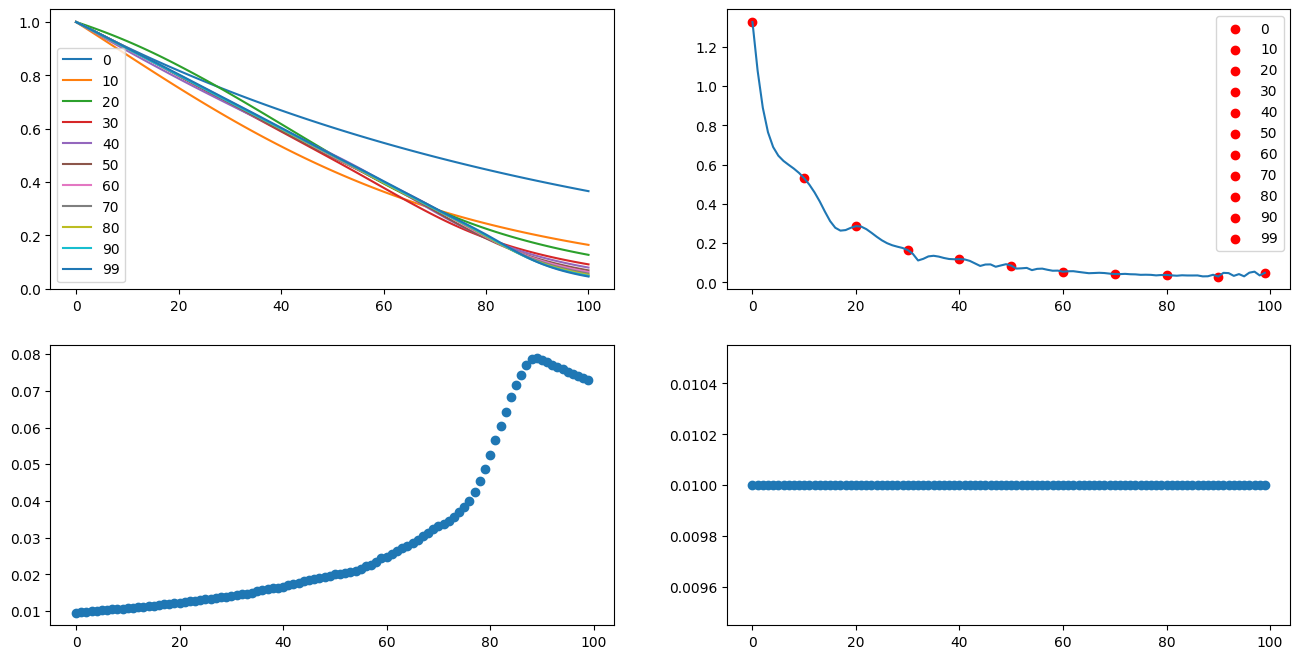

In [148]:
alpha = 0.01
N = 100
gaussians = torch.full((N,), alpha).requires_grad_(True)

adam = torch.optim.Adam([gaussians], 1e-3)

iters = 100
checkpoints = [i for i in range(iters) if i%(iters//10)==0]
if not iters -1 in checkpoints: checkpoints.append(iters-1)

Ts_over_iters = []
ls_over_iters = []

gaussians_init = gaussians.clone()
for j in range(iters):
    l = torch.tensor(0.0,dtype=torch.float32).requires_grad_(True)
    Ts = []
    T = torch.tensor(1.0, dtype=torch.float32).requires_grad_(True)
    for i in range(len(gaussians)):
        Ts.append(T.detach().item())
        T = T * (1-gaussians[i])
        target_T = 1.0 - (i + 1) / N
        l = l + 0.1 * (T - target_T).abs()
    Ts.append(T.detach().item())
    if j in checkpoints: Ts_over_iters.append(Ts)
    
    l.backward()
    ls_over_iters.append(l.detach().item())
    adam.step()
    adam.zero_grad(True)

fig, ax = plt.subplots(2,2)

for i in range(len(Ts_over_iters)):
    ls = ls_over_iters[checkpoints[i]]
    Ts = Ts_over_iters[i]
    ax[0,0].plot(Ts, label=f"{checkpoints[i]}")
    ax[0,1].scatter(checkpoints[i],ls, label=f"{checkpoints[i]}", c='r')
ax[0,1].plot(ls_over_iters)
ax[0,0].legend() 
ax[0,1].legend() 
ax[1,0].scatter([i for i in range(len(gaussians))],gaussians.detach().numpy())
ax[1,1].scatter([i for i in range(len(gaussians_init))],gaussians_init.detach().numpy())
fig.set_size_inches(16, 8)

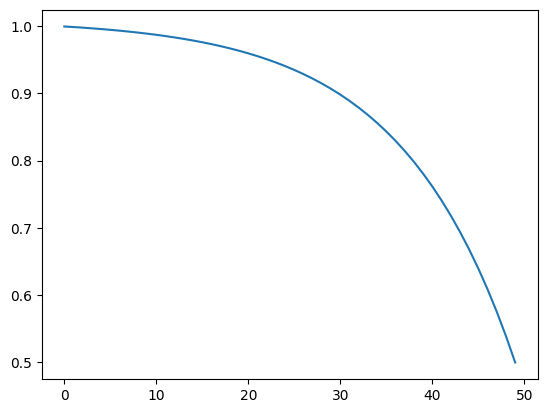

In [ ]:
max_contributor = 50
current_contributor = np.linspace(1,max_contributor, max_contributor)

x = current_contributor / max_contributor;
k = 4.0; 
exp_component = (np.exp(k * x) - 1.0) / (np.exp(k) - 1.0);
target_T = 1.0 - 0.5 * exp_component;

plt.plot(target_T)

In [158]:
import torch

def test_quadratic_gradients():
    print("=== Running Custom Solver Derivative vs PyTorch Autograd Test ===")
    
    # 1. Setup test inputs with gradients enabled
    # We choose values that mimic a ray passing through a Gaussian
    AA_val, BB_val, CC_val = 100000, -5.0, 1.2
    T_val, con_ow_val = 0.6, 0.8
    dL_dmax_depth_val = 1.0  # seed incoming gradient
    
    AA = torch.tensor(AA_val, requires_grad=True, dtype=torch.float32)
    BB = torch.tensor(BB_val, requires_grad=True, dtype=torch.float32)
    CC = torch.tensor(CC_val, requires_grad=True, dtype=torch.float32)
    T = torch.tensor(T_val, requires_grad=True, dtype=torch.float32)
    con_ow = torch.tensor(con_ow_val, requires_grad=True, dtype=torch.float32)
    
    # ==========================================
    # PATH A: PYTORCH AUTOMATIC DIFFERENTIATION
    # ==========================================
    # Replicate forward equations exactly as in C++ kernel
    log_num = torch.log(torch.clamp(2.0 * T - 1.0, min=1e-7))
    log_den = torch.log(2.0 * T) + torch.log(con_ow)
    logy = torch.clamp(log_num - log_den, min=-13.8155105579)
    
    D = CC + 2.0 * logy
    
    # Mirroring the StableQuadraticSolver logic branch:
    # Under standard conditions (is_linear is False)
    # The solver computes q based on signs:
    same_sign = (AA >= 0.0) == (BB >= 0.0)
    
    # Compute delta and clip like fmaxf(delta, 0.0f) + eps
    delta_raw = BB * BB - 4.0 * AA * D
    delta = torch.clamp(delta_raw, min=1e-6)
    
    b_sign = torch.sign(BB)
    q = -0.5 * (BB + b_sign * torch.sqrt(delta))
    
    # Choose branch based on sign layout
    if same_sign:
        x = q / AA
    else:
        x = D / q
        
    # Trigger PyTorch backward pass
    loss = x * dL_dmax_depth_val
    loss.backward()
    
    # Extract structural ground-truth gradients
    autograd_gA = AA.grad.item()
    autograd_gB = BB.grad.item()
    autograd_gC = CC.grad.item()
    autograd_go = con_ow.grad.item()
    
    # ==========================================
    # PATH B: OUR MANUAL ANALYTICAL GRADIENTS
    # ==========================================
    eps = 1e-7
    # Forward evaluation for local snapshot variables
    f_AA, f_BB, f_CC, f_D = AA_val, BB_val, CC_val, D.item()
    f_logy = logy.item()
    
    # Solver state simulation
    f_delta = f_BB * f_BB - 4.0 * f_AA * f_D
    f_valid_delta = f_delta >= 0.0 # simulation tracking flag
    
    f_b_sign = 1.0 if f_BB >= 0.0 else -1.0
    f_q = -0.5 * (f_BB + f_b_sign * torch.sqrt(torch.tensor(max(f_delta, 1e-6))).item())
    f_same_sign = (f_AA >= 0.0) == (f_BB >= 0.0)
    
    # Implementation of our math backward block
    dq_dA = 0.0
    dq_dB = -0.5
    dq_dC = 0.0 # representing dq_dD here
    
    if f_delta > 1e-6:
        inv_sqrt_delta = 1.0 / (f_delta ** 0.5)
        dq_dA = f_b_sign * f_D * inv_sqrt_delta
        dq_dB = -0.5 * (1.0 + f_b_sign * f_BB * inv_sqrt_delta)
        dq_dC = f_b_sign * f_AA * inv_sqrt_delta

    if f_same_sign:
        inv_A = 1.0 / f_AA
        grad_q = 1.0 * inv_A
        manual_gA = (-f_q / (f_AA * f_AA)) + (grad_q * dq_dA)
        manual_gB = grad_q * dq_dB
        manual_gC = grad_q * dq_dC
    else:
        grad_q = -f_D / (f_q * f_q)
        manual_gA = grad_q * dq_dA
        manual_gB = grad_q * dq_dB
        manual_gC = (1.0 / f_q) + (grad_q * dq_dC)
        
    # Propagate through D to CC and logy (dD/dCC = 1, dD/dlogy = 2)
    # manual_gC is effectively grad_D up to this point
    grad_D = manual_gC 
    manual_gCC = grad_D * 1.0
    manual_glogy = grad_D * 2.0
    
    # Propagate through opacity mapping logic
    manual_go = 0.0 if f_logy <= -13.8155105579 else -2.0 * manual_gCC / con_ow_val
    
    # Scale by incoming loss gradient layer
    manual_gA *= dL_dmax_depth_val
    manual_gB *= dL_dmax_depth_val
    manual_gCC *= dL_dmax_depth_val
    manual_go *= dL_dmax_depth_val

    # ==========================================
    # VERIFICATION REPORTING
    # ==========================================
    print(f"{'Parameter':<10} | {'PyTorch Autograd':<18} | {'Manual Analytical':<18} | {'Difference':<10}")
    print("-" * 65)
    print(f"{'dL_dAA':<10} | {autograd_gA:<18.6f} | {manual_gA:<18.6f} | {abs(autograd_gA - manual_gA):<10.2e}")
    print(f"{'dL_dBB':<10} | {autograd_gB:<18.6f} | {manual_gB:<18.6f} | {abs(autograd_gB - manual_gB):<10.2e}")
    print(f"{'dL_dCC':<10} | {autograd_gC:<18.6f} | {manual_gCC:<18.6f} | {abs(autograd_gC - manual_gCC):<10.2e}")
    print(f"{'dL_do':<10} | {autograd_go:<18.6f} | {manual_go:<18.6f} | {abs(autograd_go - manual_go):<10.2e}")
    
    # Assert tolerance threshold
    assert abs(autograd_gA - manual_gA) < 1e-5, "A Gradient mismatch!"
    assert abs(autograd_gB - manual_gB) < 1e-5, "B Gradient mismatch!"
    assert abs(autograd_gC - manual_gC) < 1e-5, "C Gradient mismatch!"
    print("\n✓ SUCCESS: Manual analytical implementation is mathematically sound!")

if __name__ == "__main__":
    # Ensure torch is available to run this script safely
    test_quadratic_gradients()

=== Running Custom Solver Derivative vs PyTorch Autograd Test ===
Parameter  | PyTorch Autograd   | Manual Analytical  | Difference
-----------------------------------------------------------------
dL_dAA     | 0.000000           | 0.000000           | 2.19e-16  
dL_dBB     | -0.000005          | -0.000005          | 2.23e-13  
dL_dCC     | 0.001136           | 0.001136           | 1.55e-10  
dL_do      | -0.002840          | -0.002840          | 2.70e-10  

✓ SUCCESS: Manual analytical implementation is mathematically sound!


In [117]:
import cv2
import numpy as np
import open3d as o3d

def compute_sharpness(image_path_or_array):
    """Computes the Laplacian variance of an image as a proxy for sharpness."""
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array, cv2.IMREAD_GRAYSCALE)
    else:
        img = image_path_or_array
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(img, cv2.CV_64F).var()


def filter_and_visualize_poses_adaptive(data_dict, pos_threshold=None, K=2.5, angle_threshold_deg=5.0):
    """Filters near cameras keeping the sharpest one, with automatic threshold estimation.

    Args:
        data_dict: dict structured as {
            img_id: {
                'w2c': np.ndarray (4x4),
                'image': np.ndarray or str (path to image)
            }
        }
        pos_threshold: Max distance to consider positions 'close'. If None, computed dynamically.
        K: Multiplier for the median consecutive position shift if pos_threshold is None.
        angle_threshold_deg: Max angle difference (in degrees) to consider orientations 'close'
    """
    img_ids = list(data_dict.keys())
    camera_centers = []
    view_dirs = []
    sharpness_scores = []
    c2w_mats = []

    # 1. Parse data and extract camera extrinsic properties
    for img_id in img_ids:
        w2c = data_dict[img_id]["w2c"]
        c2w = np.linalg.inv(w2c)
        c2w_mats.append(c2w)

        # Camera center is the translation vector of c2w
        center = c2w[:3, 3]
        camera_centers.append(center)

        # Viewing direction is the Z-axis of the camera (third column of c2w)
        view_dir = c2w[:3, 2]
        view_dirs.append(view_dir / np.linalg.norm(view_dir))

        # Sharpness calculation
        score = compute_sharpness(data_dict[img_id]["image"])
        sharpness_scores.append(score)

    camera_centers = np.array(camera_centers)
    num_cams = len(img_ids)

    # 2. Dynamic Threshold Estimation
    if pos_threshold is None:
        if num_cams > 1:
            # Compute pairwise distance matrix between all camera centers: shape (N, N)
            # Using broadcasting: (N, 1, 3) - (1, N, 3) -> (N, N, 3)
            diffs = camera_centers[:, np.newaxis, :] - camera_centers[np.newaxis, :, :]
            dist_matrix = np.linalg.norm(diffs, axis=2)
            
            # Fill the diagonal with infinity so a camera doesn't select itself as its own nearest neighbor
            np.fill_diagonal(dist_matrix, np.inf)
            
            # Find the distance to the single closest neighbor for each camera
            nearest_distances = np.min(dist_matrix, axis=1)
            
            # Compute the median spatial density step across the unstructured cloud
            median_nn_dist = np.median(nearest_distances)
            pos_threshold = median_nn_dist * K
        else:
            pos_threshold = 0.0  # Fallback for single image

    kept_indices = set()
    discarded_indices = set()

    # Sort indices by sharpness descending so we anchor groups with the highest quality frames
    sorted_indices = np.argsort(sharpness_scores)[::-1]

    # 3. Greedy Clustering Loop
    for idx in sorted_indices:
        if idx in kept_indices or idx in discarded_indices:
            continue

        kept_indices.add(idx)

        for other_idx in range(num_cams):
            if other_idx == idx or other_idx in kept_indices or other_idx in discarded_indices:
                continue

            # Distance check
            dist = np.linalg.norm(camera_centers[idx] - camera_centers[other_idx])

            # Angular alignment check
            dot_product = np.clip(np.dot(view_dirs[idx], view_dirs[other_idx]), -1.0, 1.0)
            angle = np.degrees(np.arccos(dot_product))

            if dist < pos_threshold and angle < angle_threshold_deg:
                discarded_indices.add(other_idx)

    print(f"Total input frames: {num_cams}")
    print(f"Kept (Sharp & Unique): {len(kept_indices)} | Discarded (Redundant): {len(discarded_indices)}")

    # 4. Open3D Visualization Setup
    geometries = []

    def create_camera_frustum(c2w, color, size=0.05):
        points = np.array([
            [0, 0, 0],
            [-size, -size, size * 2],
            [size, -size, size * 2],
            [size, size, size * 2],
            [-size, size, size * 2]
        ])
        points_homo = np.hstack((points, np.ones((5, 1))))
        points_world = (c2w @ points_homo.T).T[:, :3]

        lines = [[0, 1], [0, 2], [0, 3], [0, 4], [1, 2], [2, 3], [3, 4], [4, 1]]
        colors = [color for _ in range(len(lines))]

        line_set = o3d.geometry.LineSet()
        line_set.points = o3d.utility.Vector3dVector(points_world)
        line_set.lines = o3d.utility.Vector2iVector(lines)
        line_set.colors = o3d.utility.Vector3dVector(colors)
        return line_set

    for i, c2w in enumerate(c2w_mats):
        color = [0.0, 1.0, 0.0] if i in kept_indices else [1.0, 0.0, 0.0]
        geometries.append(create_camera_frustum(c2w, color, size=0.04))

    coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.15, origin=[0, 0, 0])
    geometries.append(coord_frame)

    o3d.visualization.draw_geometries(geometries, window_name="Adaptive Camera Filtering")

    filtered_dict = {img_ids[i]: data_dict[img_ids[i]] for i in kept_indices}
    return filtered_dict

to_sample = lambda x: {"w2c": x["w2c"].detach().cpu().numpy(), "image": (x[COLOR_ATTR_NAMES[COLOR_GT]].permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8)}

#data_dict = {i: to_sample(load_pth(files[i], "cpu")) for i in files.keys()}
print("Loaded")
filter_and_visualize_poses_adaptive(data_dict, None, K= 4.5)

Loaded
Total input frames: 649
Kept (Sharp & Unique): 104 | Discarded (Redundant): 545


{3: {'w2c': array([[ 0.81004125, -0.5814095 ,  0.07613257, -1.5405458 ],
         [ 0.14943795,  0.33024198,  0.9319917 , -2.6030176 ],
         [-0.567011  , -0.7435746 ,  0.3543943 ,  3.1976166 ],
         [ 0.        ,  0.        ,  0.        ,  1.        ]],
        dtype=float32),
  'image': array([[[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         ...,
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
        

In [ ]:
data_dict

{0: {'w2c': array([[ 0.46453103,  0.33068803, -0.8214964 ,  3.1255555 ],
         [ 0.25792918,  0.83691615,  0.48274618,  0.35210237],
         [ 0.847162  , -0.43613845,  0.30347946,  2.9727983 ],
         [ 0.        ,  0.        ,  0.        ,  1.        ]],
        dtype=float32),
  'image': array([[[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         ...,
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
  
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
        